In [1]:
!pip install roboflow



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 2.6 MB/s eta 0:00:00
  Attempting uninstall: typer
    Found existing installation: typer 0.27.2
    Uninstalling typer-0.27.2:
      Successfully uninstalled typer-0.27.2


In [5]:
from google.colab import userdata
from roboflow import Roboflow

API_KEY = userdata.get("ROBOFLOW_API_KEY")

rf = Roboflow(api_key=API_KEY)

project = rf.workspace("roboflow-universe-projects").project(
    "fire-and-smoke-segmentation"
)

version = project.version(11)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Fire-and-Smoke-Segmentation-11 in yolov11:: 100%|██████████| 14225/14225 [00:02<00:00, 6670.97it/s]


In [6]:
import os

print(os.listdir(dataset.location))

['valid', 'README.dataset.txt', 'train', 'data.yaml', 'test', 'README.roboflow.txt']


In [7]:
print(open(f"{dataset.location}/data.yaml").read())

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 2
names: ['fire', 'smoke']

roboflow:
  workspace: sam3
  project: fire-and-smoke-segmentation
  version: 11
  license: CC BY 4.0
  url: https://universe.roboflow.com/sam3/fire-and-smoke-segmentation/dataset/11


In [8]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 7.7 MB/s eta 0:00:00


In [9]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [11]:
model = YOLO("yolo11s-seg.pt")

results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=15,
    imgsz=640,
    batch=16,
    name="fire_smoke_seg"
)

Ultralytics 8.4.147 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Fire-and-Smoke-Segmentation-11/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=fire_smoke_seg-2, nbs=6

In [12]:
from ultralytics import YOLO

model = YOLO("/content/runs/segment/fire_smoke_seg-2/weights/best.pt")

results = model.predict(
    source=f"{dataset.location}/test/images",
    conf=0.25,
    save=True
)


image 1/20 /content/Fire-and-Smoke-Segmentation-11/test/images/flare_0014_jpg.rf.cc22023e6749a8a6833f8ad3bebf39d8.jpg: 640x640 1 fire, 20.1ms
image 2/20 /content/Fire-and-Smoke-Segmentation-11/test/images/flare_0028_jpg.rf.e6186a6977948928b5e3f6f506db0d1e.jpg: 640x640 1 fire, 20.2ms
image 3/20 /content/Fire-and-Smoke-Segmentation-11/test/images/flare_0029_jpg.rf.e0708c173fa6dc8f247f052797b2c116.jpg: 640x640 1 fire, 2 smokes, 20.0ms
image 4/20 /content/Fire-and-Smoke-Segmentation-11/test/images/flare_0057_jpg.rf.f32d04ea7efe96f214535d2d31f5d813.jpg: 640x640 (no detections), 20.0ms
image 5/20 /content/Fire-and-Smoke-Segmentation-11/test/images/flare_0058_jpg.rf.5e5076a18c95081757b5e9704115ca1a.jpg: 640x640 1 fire, 2 smokes, 20.0ms
image 6/20 /content/Fire-and-Smoke-Segmentation-11/test/images/flare_0059_jpg.rf.b092d9ab85ec3b5542407076ce1c9f86.jpg: 640x640 2 fires, 20.0ms
image 7/20 /content/Fire-and-Smoke-Segmentation-11/test/images/flare_0060_jpg.rf.82e73a111b19b4ee84348530968755ed.jpg

In [14]:
model = YOLO("/content/runs/segment/fire_smoke_seg-2/weights/best.pt")

metrics = model.val(
    data=f"{dataset.location}/data.yaml",
    split="val",
    imgsz=640,
    batch=16
)

print(metrics)

Ultralytics 8.4.147 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s-seg summary (fused): 113 layers, 10,067,590 parameters, 0 gradients, 32.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 583.5±150.3 MB/s, size: 10.5 KB)
val: Scanning /content/Fire-and-Smoke-Segmentation-11/valid/labels.cache... 40 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 40/40 14.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.1it/s 2.6s
                   all         40         97      0.738      0.735      0.727      0.509      0.712      0.709      0.699      0.474
                  fire         40         58      0.863      0.879      0.857      0.655      0.863      0.879      0.869      0.643
                 smoke         28         39      0.613       0.59      0.596      0.364       0.56      0.538      0.528      0.305
Speed: 9.4ms preprocess,

In [15]:
print("Box mAP50:", metrics.box.map50)
print("Box mAP50-95:", metrics.box.map)

print("Mask mAP50:", metrics.seg.map50)
print("Mask mAP50-95:", metrics.seg.map)

print("Mask Precision:", metrics.seg.mp)
print("Mask Recall:", metrics.seg.mr)

Box mAP50: 0.726533596601485
Box mAP50-95: 0.5093025433954023
Mask mAP50: 0.6985602301765085
Mask mAP50-95: 0.4742820070612532
Mask Precision: 0.7116926579786279
Mask Recall: 0.7088859416445623


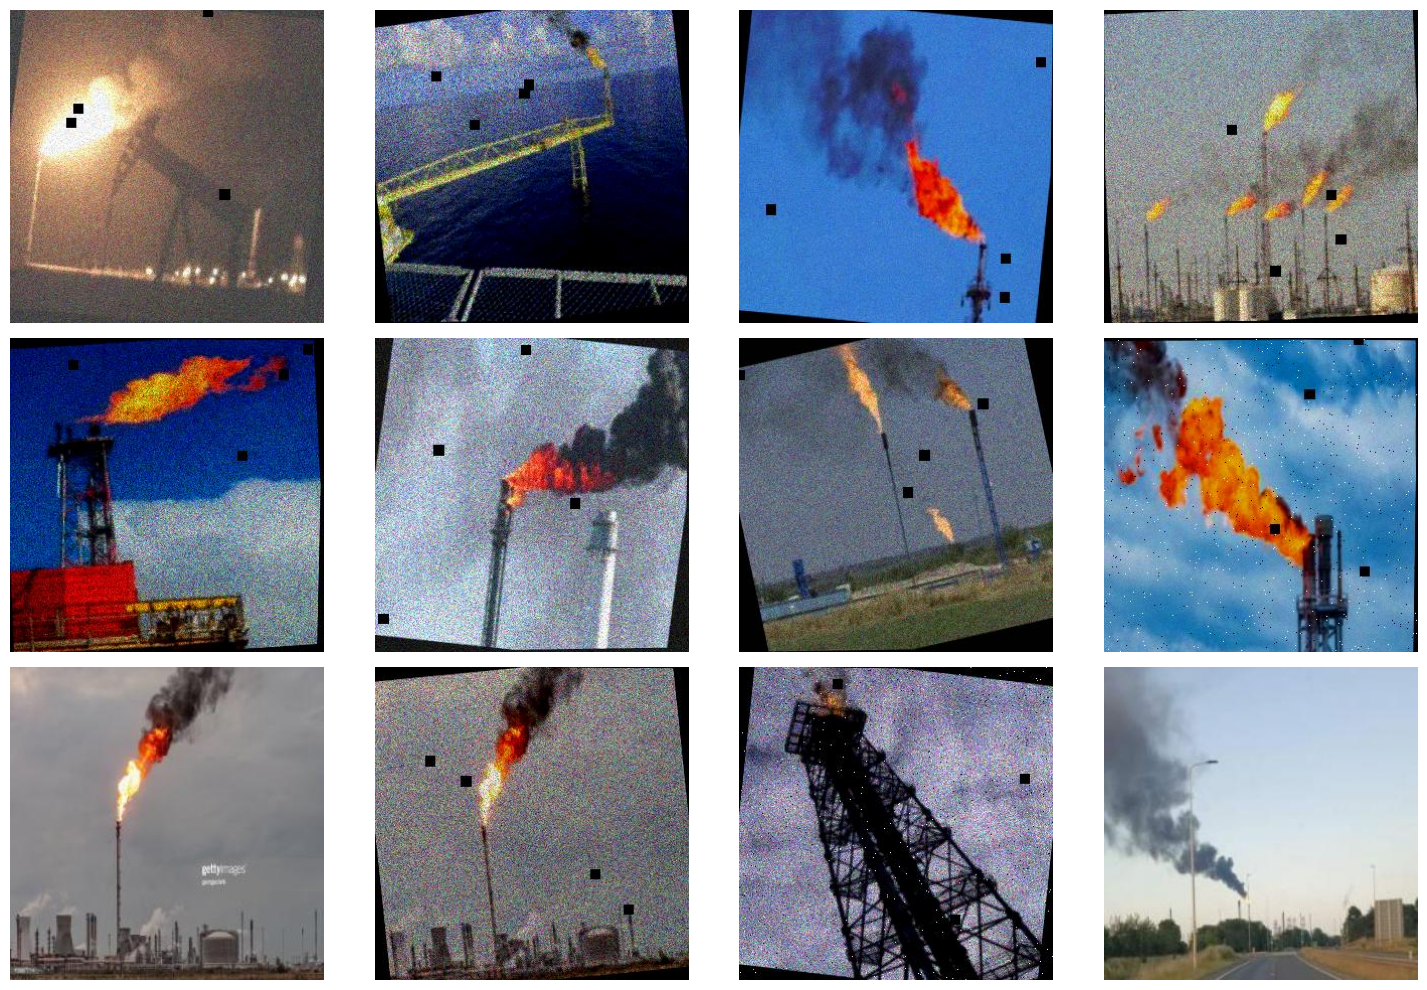

In [16]:
import matplotlib.pyplot as plt
import os
from PIL import Image

train_dir = f"{dataset.location}/train/images"

images = [
    os.path.join(train_dir, x)
    for x in os.listdir(train_dir)
    if x.lower().endswith((".jpg", ".jpeg", ".png"))
]

# عرض أول 12 صورة
plt.figure(figsize=(15, 10))

for i, img_path in enumerate(images[:12]):
    img = Image.open(img_path)

    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.axis("off")

plt.tight_layout()
plt.show()

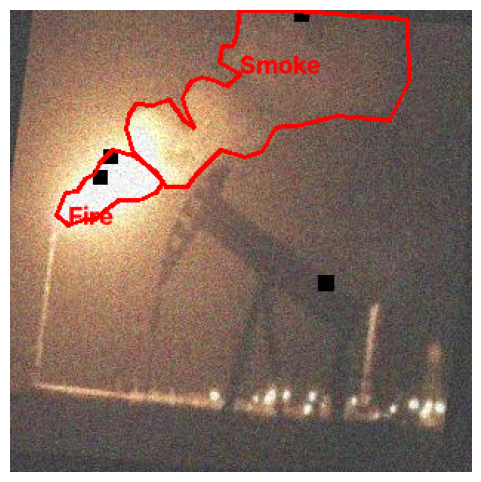

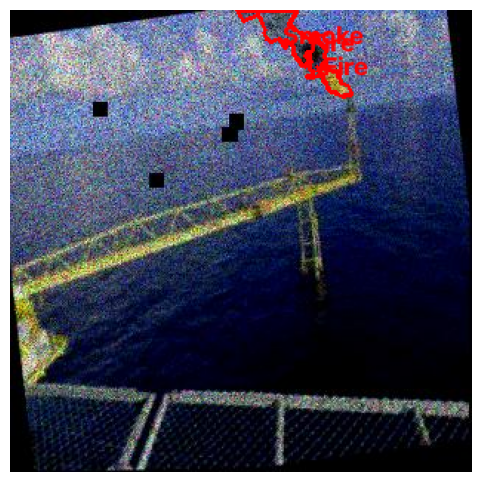

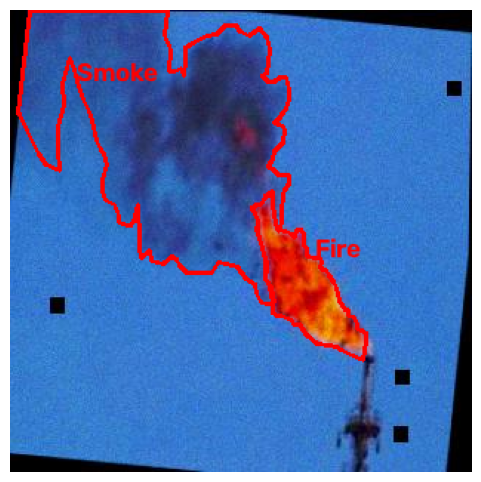

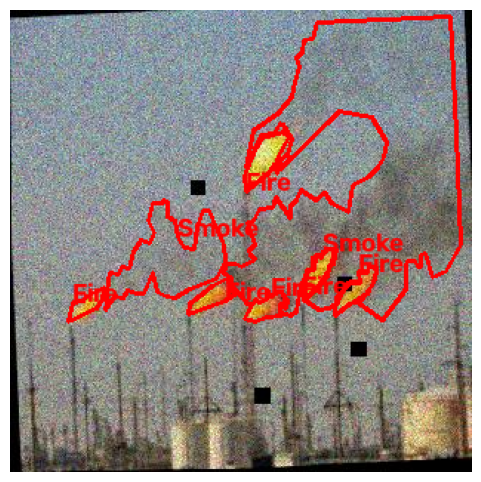

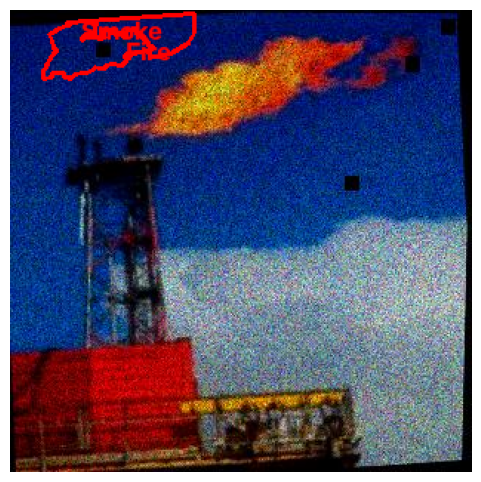

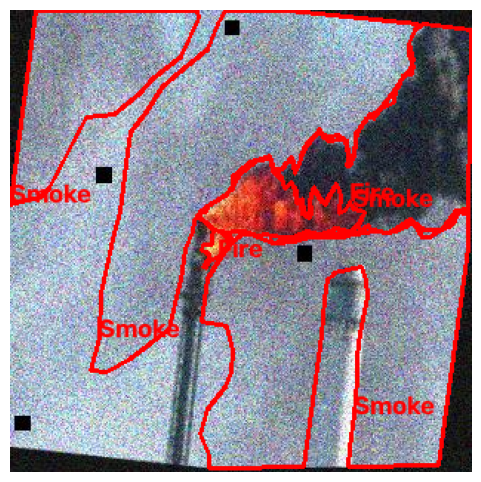

In [19]:
import cv2
import os
import matplotlib.pyplot as plt

img_dir = f"{dataset.location}/train/images"
label_dir = f"{dataset.location}/train/labels"

images = [x for x in os.listdir(img_dir)
          if x.endswith((".jpg", ".jpeg", ".png"))]

for name in images[:6]:

    img = cv2.imread(os.path.join(img_dir, name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w = img.shape[:2]
    label_path = os.path.join(label_dir, os.path.splitext(name)[0] + ".txt")

    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f:
                data = list(map(float, line.split()))
                cls = int(data[0])

                points = data[1:]
                pts = [(int(points[i] * w), int(points[i+1] * h))
                       for i in range(0, len(points), 2)]

                cv2.polylines(img, [__import__("numpy").array(pts)],
                              True, (255, 0, 0), 2)

                cv2.putText(img, ["Fire", "Smoke"][cls],
                            pts[0], cv2.FONT_HERSHEY_SIMPLEX,
                            0.6, (255, 0, 0), 2)

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.show()